In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/pima-indians-diabetes-database/diabetes.csv


# Import Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split 
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import classification_report

# Import Datasets

In [3]:
data=pd.read_csv('/kaggle/input/pima-indians-diabetes-database/diabetes.csv')
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# Data Describe

In [4]:
data.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


# Data Info

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


# Data Corr

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


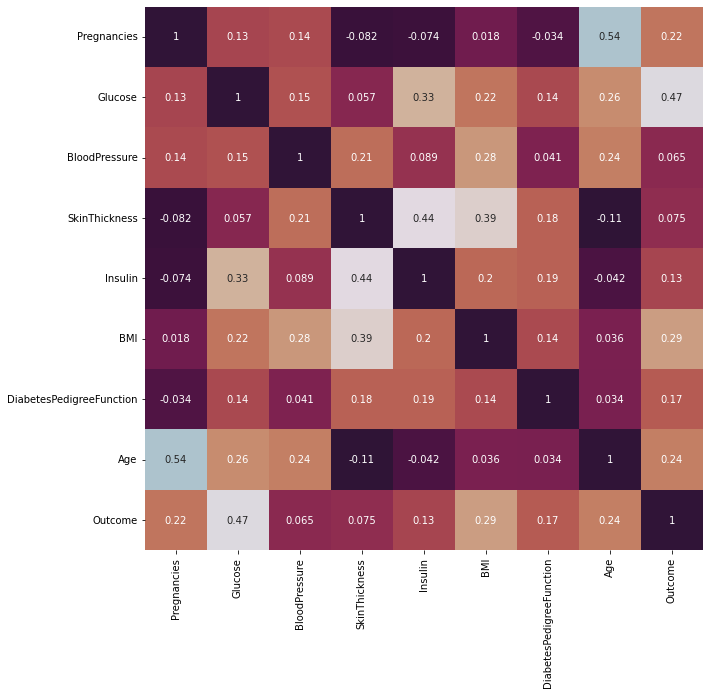

In [6]:
plt.figure(figsize=(10,10))
sns.heatmap(data.corr(),annot=True,cbar=False,cmap='twilight_shifted_r')
data.corr()

# Show Data Contain Null Data

In [7]:
data_null=pd.DataFrame(data.isnull().sum(),columns=['Number Of Null'])
data_null['Percentage Of Null']=data_null['Number Of Null']/len(data)
data_null

,Number Of Null,Percentage Of Null
Pregnancies,0,0.0
Glucose,0,0.0
BloodPressure,0,0.0
SkinThickness,0,0.0
Insulin,0,0.0
BMI,0,0.0
DiabetesPedigreeFunction,0,0.0
Age,0,0.0
Outcome,0,0.0


# Show Data Contain Duplicate Data

In [8]:
data[data.duplicated()]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome


# Data Visualization

<AxesSubplot:xlabel='Outcome', ylabel='Probability'>

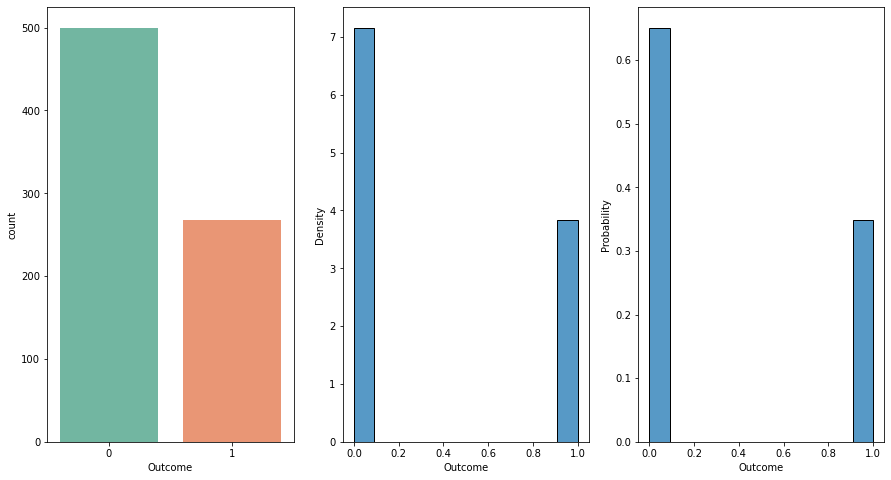

In [9]:
plt.figure(figsize=(15,8))
plt.subplot(1,3,1)
sns.countplot(x='Outcome',data=data,palette='Set2')
plt.subplot(1,3,2)
sns.histplot(x='Outcome',data=data,stat='density',palette='Set2')
plt.subplot(1,3,3)
sns.histplot(x='Outcome',data=data,stat='probability',palette='Set2')

<AxesSubplot:xlabel='SkinThickness', ylabel='Count'>

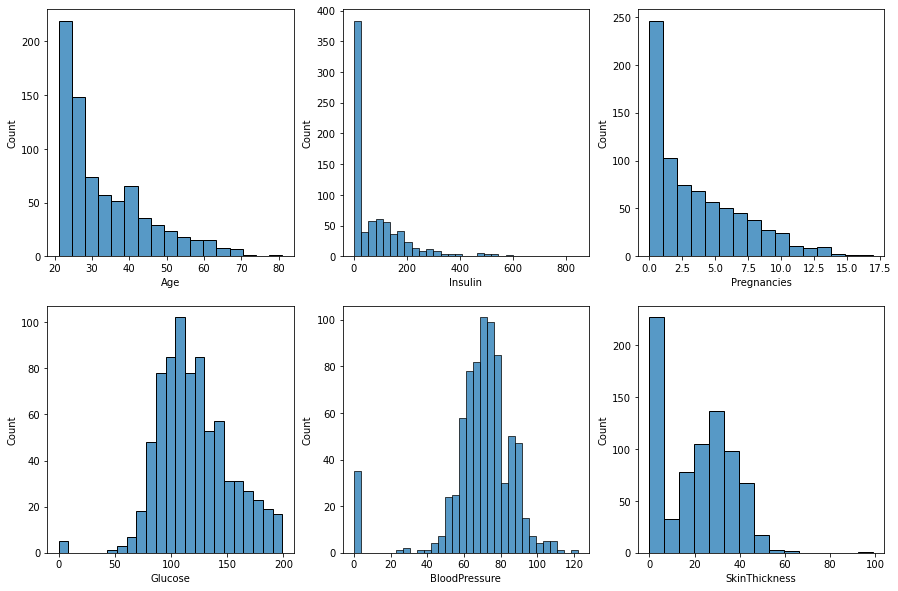

In [10]:
plt.figure(figsize=(15,10))
plt.subplot(2,3,1)
sns.histplot(x='Age',data=data)
plt.subplot(2,3,2)
sns.histplot(x='Insulin',data=data)
plt.subplot(2,3,3)
sns.histplot(x='Pregnancies',data=data)
plt.subplot(2,3,4)
sns.histplot(x='Glucose',data=data)
plt.subplot(2,3,5)
sns.histplot(x='BloodPressure',data=data)
plt.subplot(2,3,6)
sns.histplot(x='SkinThickness',data=data)

<AxesSubplot:xlabel='SkinThickness', ylabel='Count'>

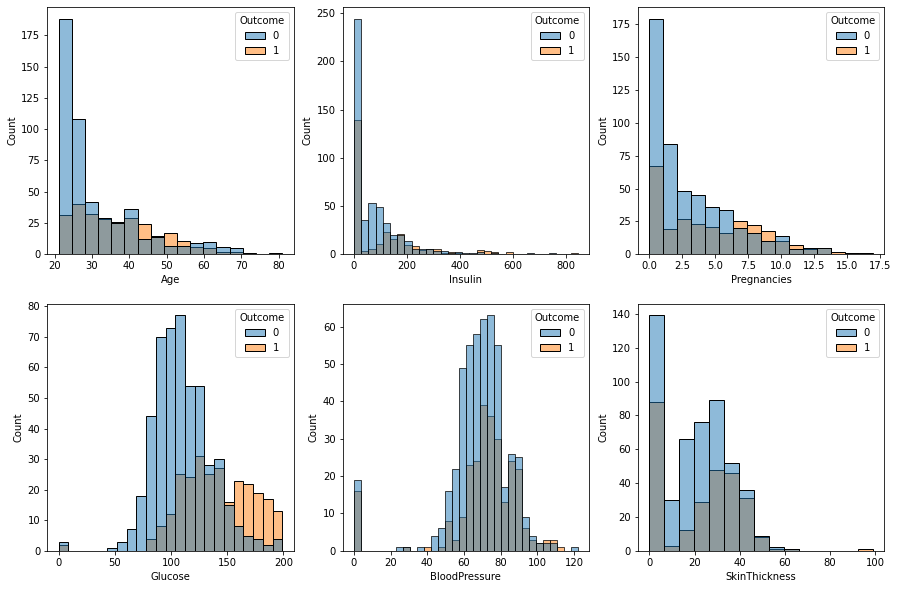

In [11]:
plt.figure(figsize=(15,10))
plt.subplot(2,3,1)
sns.histplot(x='Age',data=data,hue='Outcome')
plt.subplot(2,3,2)
sns.histplot(x='Insulin',data=data,hue='Outcome')
plt.subplot(2,3,3)
sns.histplot(x='Pregnancies',data=data,hue='Outcome')
plt.subplot(2,3,4)
sns.histplot(x='Glucose',data=data,hue='Outcome')
plt.subplot(2,3,5)
sns.histplot(x='BloodPressure',data=data,hue='Outcome')
plt.subplot(2,3,6)
sns.histplot(x='SkinThickness',data=data,hue='Outcome')

<AxesSubplot:ylabel='DiabetesPedigreeFunction'>

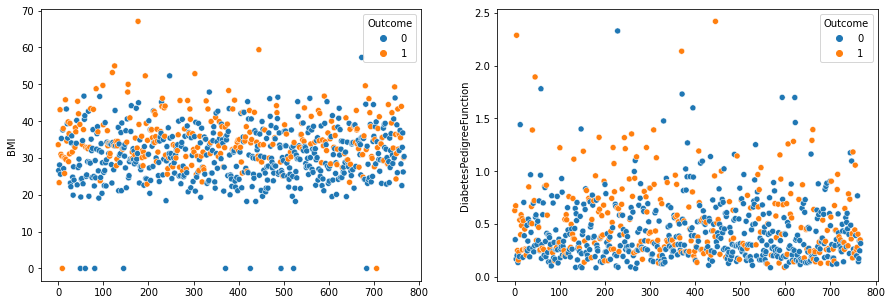

In [12]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
sns.scatterplot(x=range(len(data)),y='BMI',data=data,hue='Outcome')
plt.subplot(1,2,2)
sns.scatterplot(x=range(len(data)),y='DiabetesPedigreeFunction',data=data,hue='Outcome')

# Show Input X and Output y

In [13]:
X=data.iloc[:,:-1]
y=data.iloc[:,-1]

# Spilt Data

In [14]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.1,shuffle=True,random_state=True)
print('X_train Shape :',X_train.shape)
print('X_test Shape :',X_test.shape)
print('y_train Shape :',y_train.shape)
print('y_test Shape :',y_test.shape)

X_train Shape : (691, 8)
X_test Shape : (77, 8)
y_train Shape : (691,)
y_test Shape : (77,)


# Applying RandomForestClassifier Model 

In [15]:
RandomForestClassifierModel=RandomForestClassifier(n_estimators=100,criterion="gini", max_depth=8)
RandomForestClassifierModel.fit(X_train,y_train)
print('RandomForestClassifierModel Train Score is : ' , RandomForestClassifierModel.score(X_train, y_train))
print('RandomForestClassifierModel Test Score is : ' , RandomForestClassifierModel.score(X_test, y_test))
print('RandomForestClassifierModel features importances are : ' , RandomForestClassifierModel.feature_importances_)

RandomForestClassifierModel Train Score is :  0.9565846599131693
RandomForestClassifierModel Test Score is :  0.8051948051948052
RandomForestClassifierModel features importances are :  [0.08073772 0.28140663 0.07507007 0.05896736 0.07696813 0.16782201
 0.11907979 0.1399483 ]


<AxesSubplot:xlabel='Count'>

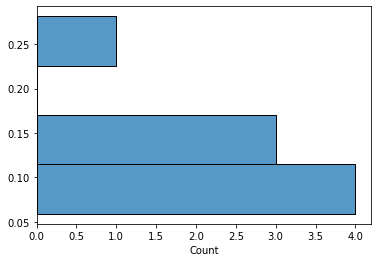

In [16]:
sns.histplot(y=RandomForestClassifierModel.feature_importances_)

# Calculating Prediction

In [17]:
y_pred = RandomForestClassifierModel.predict(X_test)
y_pred_prob = RandomForestClassifierModel.predict_proba(X_test)
print('Predicted Value for RandomForestClassifierModel is : ' , y_pred[:10])
print('Prediction Probabilities Value for RandomForestClassifierModel is : ' , y_pred_prob[:10])

Predicted Value for RandomForestClassifierModel is :  [1 0 0 0 0 0 0 0 0 0]
Prediction Probabilities Value for RandomForestClassifierModel is :  [[0.48950215 0.51049785]
 [0.74384677 0.25615323]
 [0.93498846 0.06501154]
 [0.74019449 0.25980551]
 [0.83326846 0.16673154]
 [0.74042351 0.25957649]
 [0.63568621 0.36431379]
 [0.98120556 0.01879444]
 [0.86277541 0.13722459]
 [0.81374148 0.18625852]]


# Calculating Confusion Matrix

array([[42,  6],
       [ 9, 20]])

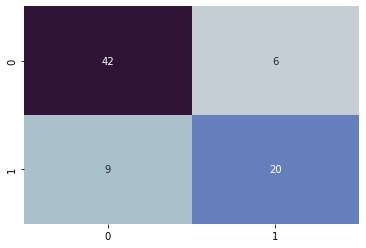

In [18]:
CM = confusion_matrix(y_test, y_pred)
sns.heatmap(CM, center = True,annot=True,cbar=False,cmap='twilight_shifted_r')
CM

# Calculating Accuracy Score  : ((TP + TN) / float(TP + TN + FP + FN))

In [19]:
AccScore = accuracy_score(y_test, y_pred, normalize=False)
print('Accuracy Score is : ', AccScore)

Accuracy Score is :  62


# Calculating F1 Score  : 2 * (precision * recall) / (precision + recall)

In [20]:
F1Score = f1_score(y_test, y_pred, average='micro') #it can be : binary,macro,weighted,samples
print('F1 Score is : ', F1Score)

F1 Score is :  0.8051948051948051


# Calculating Recall Score : (Sensitivity) (TP / float(TP + FN))

In [21]:
RecallScore = recall_score(y_test, y_pred, average='micro')
print('Recall Score is : ', RecallScore)

Recall Score is :  0.8051948051948052


# Calculating Precision recall Score :  

In [22]:
PrecisionRecallScore = precision_recall_fscore_support(y_test, y_pred, average='micro')
print('Precision Recall Score is : ', PrecisionRecallScore)

Precision Recall Score is :  (0.8051948051948052, 0.8051948051948052, 0.8051948051948051, None)


# Calculating classification Report :  

In [23]:
ClassificationReport = classification_report(y_test,y_pred)
print('Classification Report is : ', ClassificationReport )

Classification Report is :                precision    recall  f1-score   support

           0       0.82      0.88      0.85        48
           1       0.77      0.69      0.73        29

    accuracy                           0.81        77
   macro avg       0.80      0.78      0.79        77
weighted avg       0.80      0.81      0.80        77



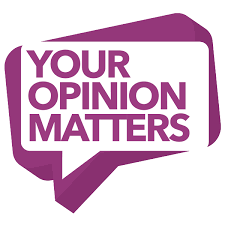
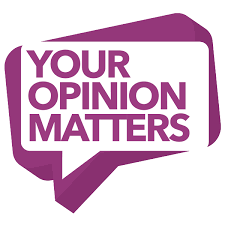